EDA of housing price econometrics

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import os
from pathlib import Path
p = Path.cwd()
while not (p / 'data').exists() and p != p.parent:
    p = p.parent
os.chdir(p)
print('рабочая папка:', os.getcwd())

рабочая папка: c:\Users\sea\Desktop\---\housing-price-econometrics


In [34]:
#загружаем данные
df = pd.read_csv('data/raw/AmesHousing.csv', encoding='latin1')

In [35]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

Первичные выводы:
Размер данных: 2930 Целевая, 82 признака
Пропусков в индексе нет, память ~1,8МВ
Итого 39 (11+28) числовых и 43 категориальных признака
Целевая переменная SalePrice - результат продажи ( следствие всех характеристик дома)

In [36]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


Целевая переменная SalePrice, количество 2930, среднее 180796, стандартное отклонение 79887, минимум 12789, 25 процентиль 129500, медиана 160000, 75 процентиль 213500, максимум 755000.
Видно, что среднее (180796) выше медианы (160000) - это значит, что имеется положительная правосторонняя асимметрия, это значит, что есть небольшое кол-во значений, которые перетягивают на себя. Это значит, что нам надо будет произвести трансформацию (логарифмическое преобразование).

In [37]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64


произведен счетчик пропусков из 82 колонок.Топ-5: Pool QC (99.6%), Misc Feature (96.4%), Alley (93.2%), Fence (80.5%), Mas Vnr Type (60.6%). Видно, что большинство колонок с пропусками Pool QC- 2917 пропусков (почти все), это значит что у 2917 домов нет бассейна, Misc Feature- 2824, Alley- 2732. В Ames пропуски в категориальных колонках часто означают отсутствие объектов. А для числовых это скорее всего означает "неизвестно", и надо решить, как заполнять.

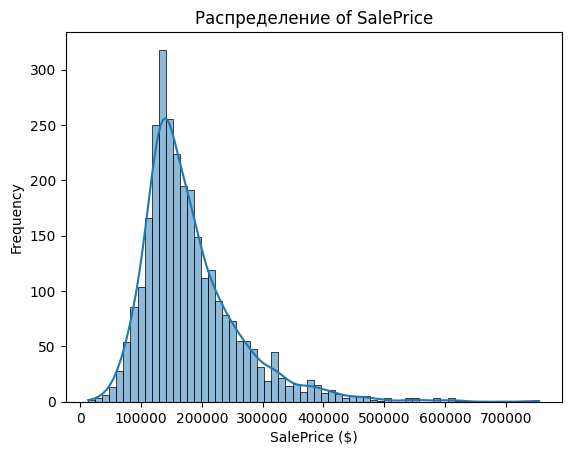

Skewness, асимметрия: 1.74
Kurtosis, эксцесс: 5.12


In [38]:
#гистограмма +KDE
sns.histplot(df['SalePrice'], kde=True)
plt.title('Распределение of SalePrice')
plt.xlabel('SalePrice ($)')
plt.ylabel('Frequency')
plt.show()
# числовые метрики
print(f"Skewness, асимметрия: {df['SalePrice'].skew():.2f}")
print(f"Kurtosis, эксцесс: {df['SalePrice'].kurt():.2f}")

Гистограмма показывает как распределены цены домов. По оси Х откладывается сама цена. Единица измерения доллары. По оси У откладывается частота - сколько домов попало в каждый ценовой интервал. 
Также с графика можно сделать вывод, что у нас правосторонняя асимметрия. Длинный хвост справа. Большинство значений маленькие, но есть несколько очень больших, которые тянут хвост вправо.
Ниже выведены числовые данные асимметрии и эксцесса. Асимметрия равна 1,74>0, это снова же подтверждает что у нас правосторонняя асимметрия. Эксцесс>0, это показывает, что пик высокий и острый, а "хвосты" длинные и тяжелые. Из этого можно сделать вывод, что в данных часто встречаются резкие скачки, аномалии.
Правосторонняя асимметрия подтверждает необходимость лог-трансформации SalePrice. После лог-трансформации эксцесс и асимметрия должны будут приблизиться к 0.